# Bank Employee Attrition Analysis

# Task 1: Problem Statement & Exploratory Data Analysis (EDA)

# Objective

The objective of this task is to understand the employee attrition dataset, examine its structure, identify missing values, analyze employee demographics, and perform basic exploratory data analysis before data preprocessing and advanced analysis.

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset

df = pd.read_csv("bank_employee_attrition.csv")

# Display first 5 records

df.head()

,MMMM_YY,Employee_ID,Age,Gender,City,Education_Level,Department,Income,Date_Of_Joining,LastWorkingDate,Joining_Designation,Grade,Total_Business_Value,Quarterly_Rating,Overtime_Flag
0,Jan-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,11806,2.0,0
1,Feb-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,16644,1.0,0
2,Mar-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,26253,3.0,1
3,Apr-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,-12414,1.0,1
4,May-21,10001,29.0,0,BLR,1,Operations,64380.0,17-08-2018,21-08-2021,Analyst,C,39153,2.0,0


In [4]:
# Check column names

df.columns

Index(['MMMM_YY', 'Employee_ID', 'Age', 'Gender', 'City', 'Education_Level',
       'Department', 'Income', 'Date_Of_Joining', 'LastWorkingDate',
       'Joining_Designation', 'Grade', 'Total_Business_Value',
       'Quarterly_Rating', 'Overtime_Flag'],
      dtype='object')

In [5]:
# Check shape of dataset

df.shape

(10816, 15)

In [6]:
# Display column information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10816 entries, 0 to 10815
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   MMMM_YY               10816 non-null  object 
 1   Employee_ID           10816 non-null  int64  
 2   Age                   10610 non-null  float64
 3   Gender                10816 non-null  int64  
 4   City                  10816 non-null  object 
 5   Education_Level       10816 non-null  int64  
 6   Department            10816 non-null  object 
 7   Income                10276 non-null  float64
 8   Date_Of_Joining       10816 non-null  object 
 9   LastWorkingDate       1528 non-null   object 
 10  Joining_Designation   10816 non-null  object 
 11  Grade                 10816 non-null  object 
 12  Total_Business_Value  10816 non-null  int64  
 13  Quarterly_Rating      10481 non-null  float64
 14  Overtime_Flag         10816 non-null  int64  
dtypes: float64(3), int6

In [7]:
# Count missing values

df.isnull().sum()

MMMM_YY                    0
Employee_ID                0
Age                      206
Gender                     0
City                       0
Education_Level            0
Department                 0
Income                   540
Date_Of_Joining            0
LastWorkingDate         9288
Joining_Designation        0
Grade                      0
Total_Business_Value       0
Quarterly_Rating         335
Overtime_Flag              0
dtype: int64

In [8]:
# Calculate missing value percentage

(df.isnull().sum() / len(df)) * 100

MMMM_YY                  0.000000
Employee_ID              0.000000
Age                      1.904586
Gender                   0.000000
City                     0.000000
Education_Level          0.000000
Department               0.000000
Income                   4.992604
Date_Of_Joining          0.000000
LastWorkingDate         85.872781
Joining_Designation      0.000000
Grade                    0.000000
Total_Business_Value     0.000000
Quarterly_Rating         3.097263
Overtime_Flag            0.000000
dtype: float64

In [9]:
# Check duplicate records

df.duplicated().sum()

np.int64(0)

In [10]:
# Summary statistics

df.describe()

,Employee_ID,Age,Gender,Education_Level,Income,Total_Business_Value,Quarterly_Rating,Overtime_Flag
count,10816.000000,10610.000000,10816.000000,10816.000000,10276.000000,10816.000000,10481.000000,10816.000000
mean,10251.120470,38.772290,0.374723,1.252219,55969.390911,69318.365200,2.686480,0.320821
std,143.877924,9.848441,0.484074,0.694470,16879.821090,62353.496693,0.940692,0.466814
min,10001.000000,23.000000,0.000000,0.000000,22000.000000,-110199.000000,1.000000,0.000000
25%,10129.000000,30.000000,0.000000,1.000000,43889.000000,26128.500000,2.000000,0.000000
50%,10251.000000,39.000000,0.000000,1.000000,55915.000000,55308.500000,3.000000,0.000000
75%,10375.000000,48.000000,1.000000,2.000000,67482.000000,107300.000000,3.000000,1.000000
max,10500.000000,54.000000,1.000000,2.000000,120460.000000,317143.000000,5.000000,1.000000


In [11]:
# Count unique values in categorical columns

print("Unique Departments:", df['Department'].nunique())

print("Unique Cities:", df['City'].nunique())

print("Unique Grades:", df['Grade'].nunique())

print("Unique Gender Categories:", df['Gender'].nunique())

Unique Departments: 6
Unique Cities: 8
Unique Grades: 5
Unique Gender Categories: 2


In [12]:
# Mean Median Std

cols = ['Age','Income','Total_Business_Value','Quarterly_Rating']

for col in cols:
    print("\n", col)
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Std:", df[col].std())


 Age
Mean: 38.77229029217719
Median: 39.0
Std: 9.848440769585517

 Income
Mean: 55969.39091086026
Median: 55915.0
Std: 16879.821090485013

 Total_Business_Value
Mean: 69318.36519970415
Median: 55308.5
Std: 62353.496692730834

 Quarterly_Rating
Mean: 2.686480297681519
Median: 3.0
Std: 0.9406923640980518


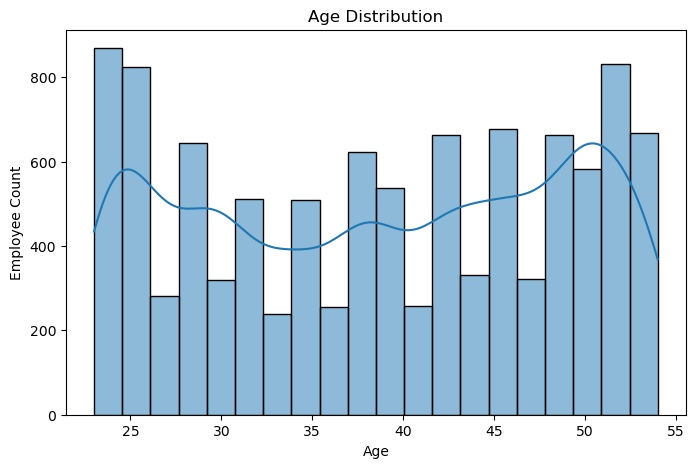

In [28]:
# Plot Age Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Employee Count")

plt.show()

# Age Distribution - Insights

- Most employees belong to the age group between 25 and 55 years.
- Employee count is relatively higher around the age range of 45–52 years.
- The workforce consists mainly of mid-career and experienced employees.

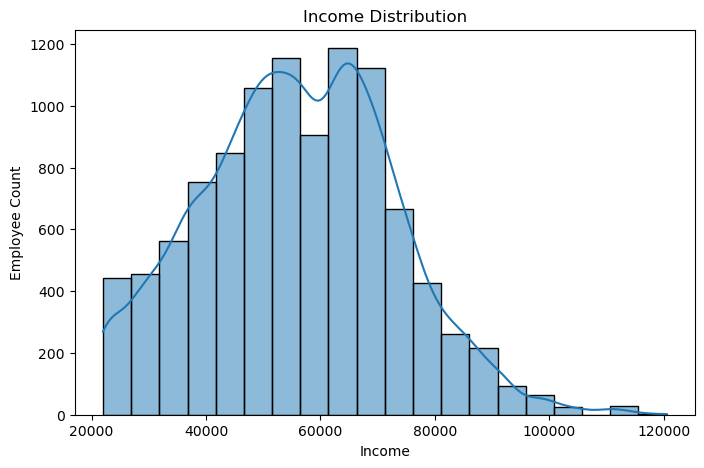

In [16]:
# Plot Income Distribution

plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=20, kde=True)

plt.title("Income Distribution")

plt.xlabel("Income")

plt.ylabel("Employee Count")

plt.show()

# Income Distribution - Insights

- Most employees earn salaries between 40,000 and 75,000.
- The income distribution is slightly right-skewed due to a few high-income employees.
- Very few employees have salaries above 100,000.

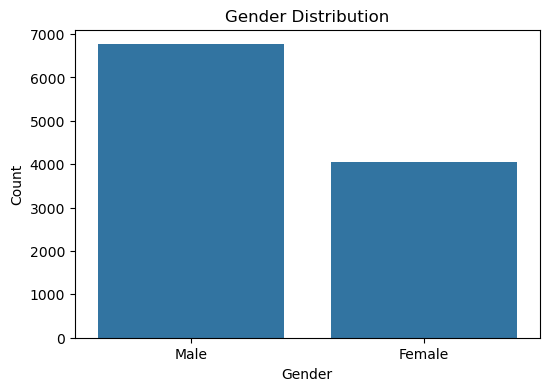

In [25]:
# Plot Gender Distribution

plt.figure(figsize=(6,4))

df['Gender'] = df['Gender'].replace({0:'Male', 1:'Female'})

sns.countplot(x='Gender', data=df)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

# Gender Distribution - Insights

- Male employees are significantly higher than female employees.
- Female employee representation is comparatively lower in the organization.
- The workforce does not appear to be gender-balanced.

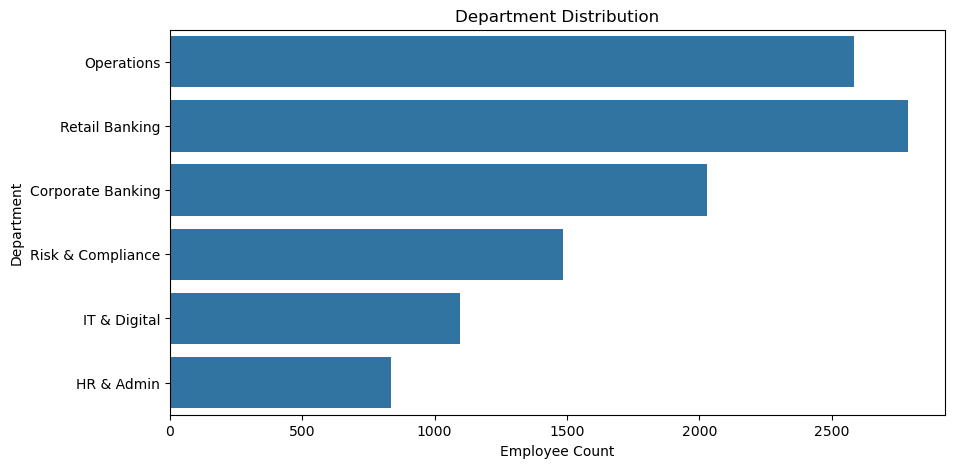

In [18]:
# Plot Department Distribution

plt.figure(figsize=(10,5))

sns.countplot(y='Department', data=df)

plt.title("Department Distribution")

plt.xlabel("Employee Count")

plt.ylabel("Department")

plt.show()

# Department Distribution - Insights

- Retail Banking has the highest number of employees.
- HR & Admin has the lowest employee count among all departments.
- Operations and Corporate Banking also contribute a large portion of the workforce.

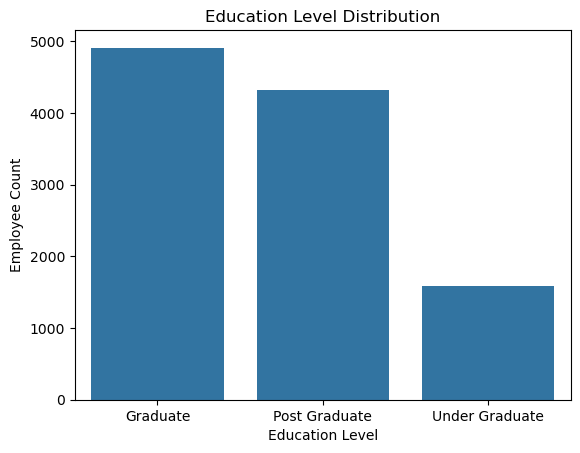

In [27]:
# Plot Education Level Distribution

sns.countplot(
    x=df['Education_Level'].replace({
        0:'Under Graduate',
        1:'Graduate',
        2:'Post Graduate'
    })
)

plt.title("Education Level Distribution")

plt.xlabel("Education Level")

plt.ylabel("Employee Count")

plt.show()

# Education Level Distribution - Insights

- Most employees are Graduates and Post-Graduates.
- Undergraduate employees are comparatively fewer in number.
- Higher educational qualifications dominate the workforce.

C:\Users\Muneeza\AppData\Local\Temp\ipykernel_28636\541158935.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date_Of_Joining'] = pd.to_datetime(df['Date_Of_Joining'])


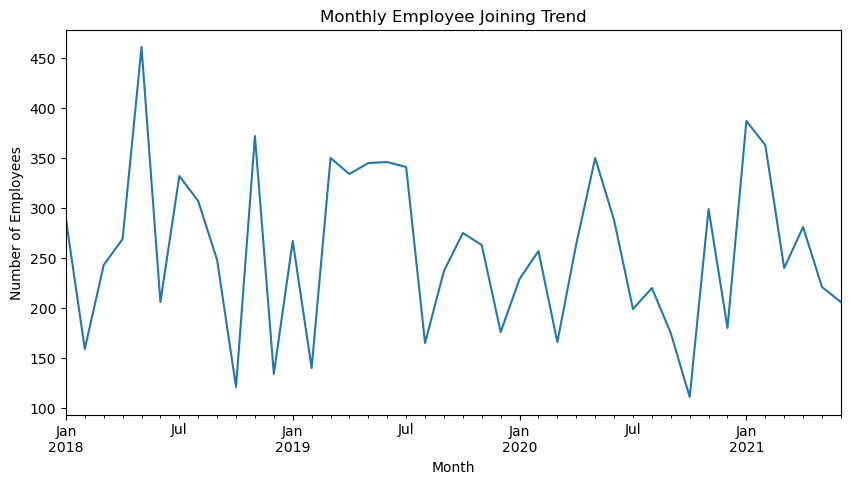

In [20]:
# Convert joining date into datetime format

df['Date_Of_Joining'] = pd.to_datetime(df['Date_Of_Joining'])

# Monthly joining trend

df['Date_Of_Joining'].dt.to_period('M').value_counts().sort_index().plot(figsize=(10,5))

plt.title("Monthly Employee Joining Trend")

plt.xlabel("Month")

plt.ylabel("Number of Employees")

plt.show()

# Monthly Employee Joining Trend - Insights

- Employee hiring fluctuates across different months and years.
- Certain periods show sharp increases in hiring activity.
- The organization appears to have seasonal or business-driven recruitment trends.

C:\Users\Muneeza\AppData\Local\Temp\ipykernel_28636\2313580761.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])


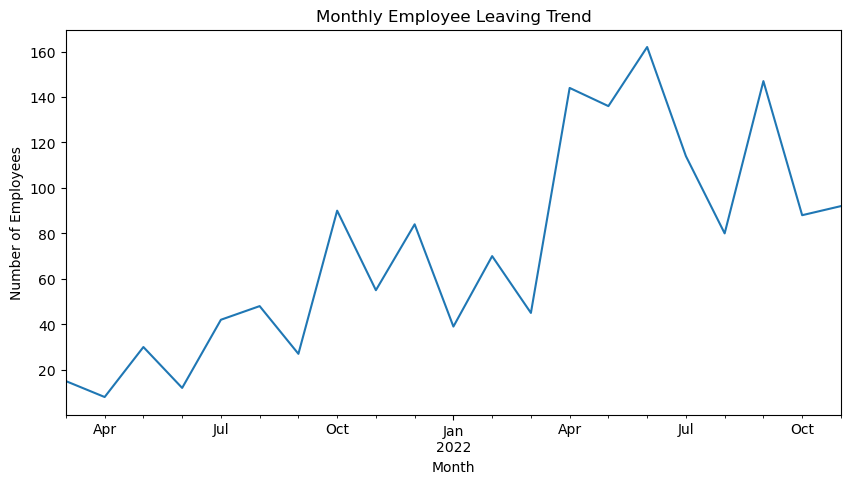

In [21]:
# Convert Last Working Date into datetime format

df['LastWorkingDate'] = pd.to_datetime(df['LastWorkingDate'])

# Monthly leaving trend

df['LastWorkingDate'].dt.to_period('M').value_counts().sort_index().plot(figsize=(10,5))

plt.title("Monthly Employee Leaving Trend")

plt.xlabel("Month")

plt.ylabel("Number of Employees")

plt.show()

# Monthly Employee Leaving Trend - Insights

- Employee exits increased significantly during 2022.
- Some months experienced noticeably higher attrition levels.
- The trend indicates growing employee turnover over time.

# Conclusion

- Dataset structure and data types were examined.
- Missing values and duplicate records were identified.
- Summary statistics were generated for numerical variables.
- Employee demographics such as age, gender, department, and education level were analyzed.
- Monthly joining and leaving trends were explored.
- The dataset is now ready for data preprocessing and feature engineering.